#### Importing the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

#### Loading the dataset

In [2]:
df = pd.read_csv('yellow_tripdata_2020_01.csv')

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


#### Exploratory Data analysis

In [4]:
df.shape

(6405008, 18)

In [5]:
df.dtypes

VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

In [6]:
# coverting the tpep_pickup_datetime and tpep_dropoff_datetime from object data type to datetime data type
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [7]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds()/60

In [8]:
# selecting the column which is required for analysis
df = df[['passenger_count','payment_type','fare_amount','trip_distance','duration']]

In [9]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.00,1.20,4.800000
1,1.0,1.0,7.00,1.20,7.416667
2,1.0,1.0,6.00,0.60,6.183333
3,1.0,1.0,5.50,0.80,4.850000
4,1.0,2.0,3.50,0.00,2.300000
...,...,...,...,...,...
6405003,NaN,NaN,17.59,3.24,31.000000
6405004,NaN,NaN,46.67,22.13,76.000000
6405005,NaN,NaN,48.85,10.51,27.833333
6405006,NaN,NaN,27.17,5.49,22.650000


In [10]:
# checking for null values
df.isnull().sum()

passenger_count    65441
payment_type       65441
fare_amount            0
trip_distance          0
duration               0
dtype: int64

In [11]:
# dropping the null values and saving the changes
df.dropna(inplace = True)

In [12]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.0,1.20,4.800000
1,1.0,1.0,7.0,1.20,7.416667
2,1.0,1.0,6.0,0.60,6.183333
3,1.0,1.0,5.5,0.80,4.850000
4,1.0,2.0,3.5,0.00,2.300000
...,...,...,...,...,...
6339562,1.0,1.0,11.0,2.10,14.233333
6339563,1.0,1.0,13.0,2.13,19.000000
6339564,1.0,1.0,12.5,2.55,16.283333
6339565,1.0,2.0,8.5,1.61,9.633333


In [13]:
# changing the data types from floating to int data types
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')

In [14]:
df.dtypes

passenger_count      int64
payment_type         int64
fare_amount        float64
trip_distance      float64
duration           float64
dtype: object

In [15]:
# checking for duplicate data
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
2056,1,2,7.0,0.00,0.000000
2441,1,1,52.0,0.00,0.200000
2446,2,1,9.5,1.70,13.066667
2465,1,1,4.0,0.40,3.083333
3344,1,1,6.0,1.20,5.350000
...,...,...,...,...,...
6339558,1,2,8.0,1.63,8.800000
6339559,1,1,8.5,1.81,8.016667
6339560,1,2,6.5,0.98,6.900000
6339562,1,1,11.0,2.10,14.233333


In [16]:
# dropping the duplicate data and saving the changes
df.drop_duplicates(inplace = True)

In [17]:
df.shape

(3007861, 5)

In [18]:
# checking the percentage contribution by each
df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64

In [19]:
# checking the percentage contribution by each payment type
df['payment_type'].value_counts(normalize = True)

payment_type
1    6.782670e-01
2    3.075731e-01
3    8.721480e-03
4    5.438084e-03
5    3.324622e-07
Name: proportion, dtype: float64

In [20]:
# filtering the data where payment type is less than 3 i.e cash and credit
# filter the passenger_count where it is greater than 0 but less than 6
df = df[df['payment_type']<3]
df = df[(df['passenger_count'] >0) &(df['passenger_count']<6)]

In [21]:
df.shape

(2780283, 5)

In [22]:
# replacing 1 as card payment_type and 2 as cash payment_type
df['payment_type'].replace([1,2],['card','cash'],inplace = True)

In [23]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.733386e+00,1.780567e+01,4.536729e+00,2.415478e+01
std,1.176652e+00,1.506997e+01,4.895890e+00,9.260031e+01
min,1.000000e+00,-5.000000e+02,-2.218000e+01,-2.770367e+03
25%,1.000000e+00,9.000000e+00,1.500000e+00,9.883333e+00
50%,1.000000e+00,1.300000e+01,2.730000e+00,1.573333e+01
75%,2.000000e+00,2.100000e+01,5.470000e+00,2.336667e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


In [24]:
# filtering the negative values
df = df[df['fare_amount']>0]
df = df[df['trip_distance']>0]
df = df[df['duration']>0]

In [25]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.748932e+06,2.748932e+06,2.748932e+06,2.748932e+06
mean,1.738151e+00,1.766835e+01,4.583313e+00,2.418261e+01
std,1.179440e+00,1.447531e+01,4.897806e+00,9.272285e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,9.000000e+00,1.530000e+00,9.950000e+00
50%,1.000000e+00,1.300000e+01,2.770000e+00,1.575000e+01
75%,2.000000e+00,2.100000e+01,5.500000e+00,2.333333e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


In [38]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,card,6.0,1.20,4.800000
1,1,card,7.0,1.20,7.416667
2,1,card,6.0,0.60,6.183333
3,1,card,5.5,0.80,4.850000
5,1,cash,2.5,0.03,0.883333
...,...,...,...,...,...
6339550,4,card,10.5,2.40,12.383333
6339555,3,card,10.0,2.09,14.800000
6339561,1,card,17.5,4.11,21.500000
6339563,1,card,13.0,2.13,19.000000


In [26]:
df.shape

(2748932, 5)

(array([2.748913e+06, 1.600000e+01, 1.000000e+00, 0.000000e+00,
        1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([1.000000e-02, 4.265090e+02, 8.530080e+02, 1.279507e+03,
        1.706006e+03, 2.132505e+03, 2.559004e+03, 2.985503e+03,
        3.412002e+03, 3.838501e+03, 4.265000e+03]),
 <BarContainer object of 10 artists>)

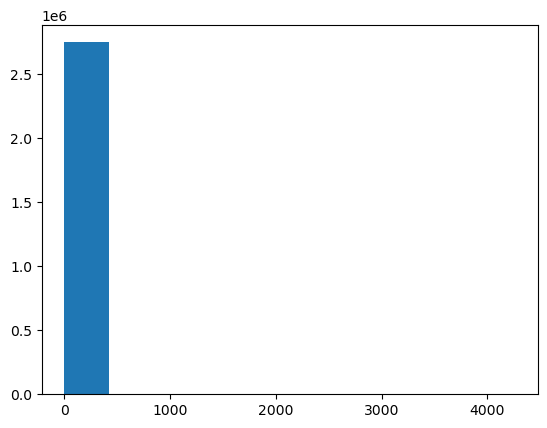

In [27]:
# checking for the outliers
plt.hist(df['fare_amount'])

In [28]:
# Removing the outliers using IQR
for col in ['fare_amount','trip_distance','duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1-1.5 * iqr
    upper_bound = q3+1.5 * iqr

    df = df[(df[col]>= lower_bound) & (df[col]<=upper_bound)]

In [29]:
df.shape

(2297908, 5)

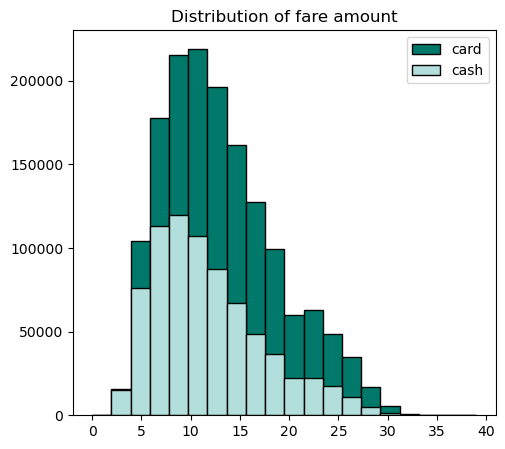

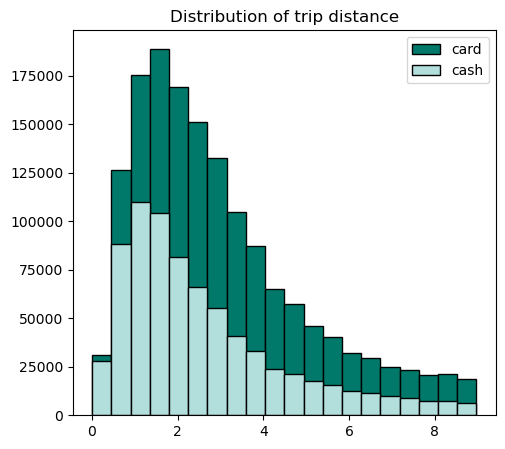

In [30]:
# checking the distibution of fare amount based on the payment type
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.title('Distribution of fare amount')
plt.hist(df[df['payment_type'] == 'card']['fare_amount'],histtype = 'barstacked',bins = 20,edgecolor = 'k',color = '#00796B',label='card')
plt.hist(df[df['payment_type'] == 'cash']['fare_amount'],histtype = 'barstacked',bins = 20,edgecolor = 'k',color = '#B2DFDB',label='cash')
plt.legend()

# checking the distibution of trip distance based on the payment type
plt.figure(figsize = (12,5))
plt.subplot(1,2,2)
plt.title('Distribution of trip distance')
plt.hist(df[df['payment_type'] == 'card']['trip_distance'],histtype = 'barstacked',bins = 20,edgecolor = 'k',color = '#00796B',label='card')
plt.hist(df[df['payment_type'] == 'cash']['trip_distance'],histtype = 'barstacked',bins = 20,edgecolor = 'k',color = '#B2DFDB',label='cash')
plt.legend()

plt.show()

In [31]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount           trip_distance         
                    mean       std          mean      std
payment_type                                             
card           13.112493  5.849281      2.992237  1.99274
cash           11.758005  5.613038      2.602207  1.91372

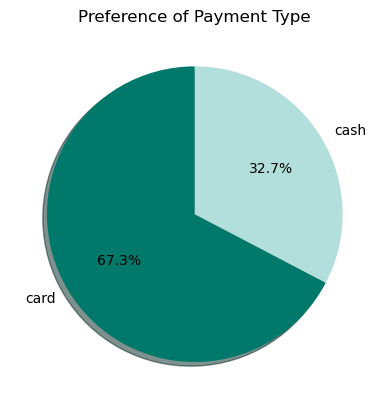

In [32]:
# percentage contribution of each
plt.title('Preference of Payment Type')
plt.pie(df['payment_type'].value_counts(normalize = True),labels = df['payment_type'].value_counts().index,
        startangle = 90,shadow = True,autopct = '%1.1f%%',colors = ['#00796B', '#B2DFDB'])
plt.show()
        

In [33]:
df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()

passenger_count
payment_type passenger_count                 
card         1                         909245
             2                         327661
             3                         122412
             4                          63676
             5                         124045
cash         1                         460550
             2                         155472
             3                          54506
             4                          32715
             5                          47626

In [43]:
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns =  {'passenger_count':'count'},inplace = True)
passenger_count.reset_index(inplace = True)

In [44]:
passenger_count['perc'] = (passenger_count['count']/passenger_count['count'].sum())*100

In [55]:
df = pd.DataFrame(columns = ['payment_type',1,2,3,4,5])
df['payment_type'] = ['card','cash']
df.iloc[0,1:] = passenger_count.iloc[0:5,-1]
df.iloc[1,1:] = passenger_count.iloc[5:,-1]
df

,payment_type,1,2,3,4,5
0,card,39.568381,14.2591,5.327106,2.771042,5.398171
1,cash,20.042143,6.765806,2.371984,1.423686,2.072581


<Axes: ylabel='payment_type'>

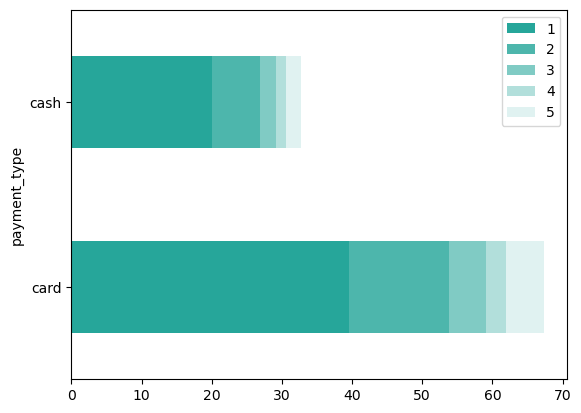

In [56]:
df.plot(x = 'payment_type' , kind = 'barh',stacked = True, color = ['#26A69A', '#4DB6AC','#80CBC4','#B2DFDB', '#E0F2F1' ])

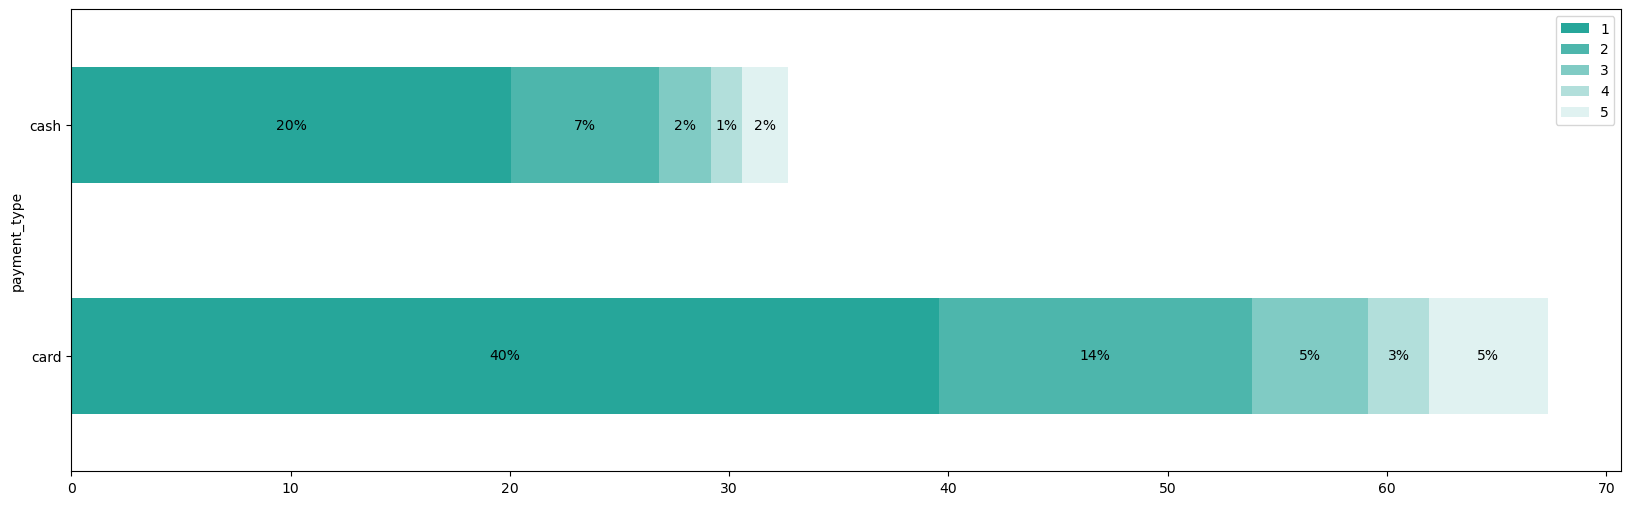

In [57]:
fig,ax = plt.subplots(figsize = (20,6))
df.plot(x = 'payment_type' , kind = 'barh',stacked = True,ax = ax, color = ['#26A69A', '#4DB6AC','#80CBC4','#B2DFDB', '#E0F2F1' ])
# Add percentage text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x,y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}%'.format(width),
             horizontalalignment = 'center',
             verticalalignment = 'center')

#### Null hypothesis: There is no difference in average fare between customers who use credit cards and customer who use cash.
#### Alternate hypothesis: There is a difference in average fare between customers who use credit cards and customer who use cash.

In [34]:
import statsmodels.api as sm

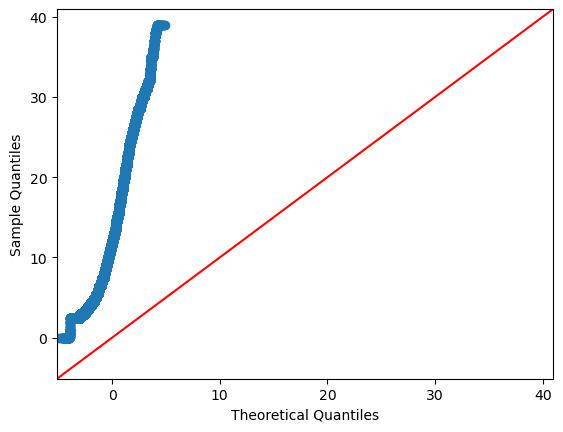

In [35]:
sm.qqplot(df['fare_amount'],line = '45')
plt.show()

In [36]:
card_sample = df[df['payment_type']=='card']['fare_amount']
cash_sample = df[df['payment_type']=='cash']['fare_amount']

In [37]:
t_stats,p_value = st.ttest_ind(a = card_sample , b = cash_sample,equal_var = False)
print('T statistic', t_stats, 'p_value',p_value)

T statistic 169.21115272450405 p_value 0.0
